In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

In [2]:
df = pd.read_csv("final_travel_dataset.csv")

print(df.shape)
df.head()

(81104, 25)


,travelCode,user_id,source_city,destination_city,flightType,price_flight,time,distance,agency,date_flight,...,place,days,price_hotel,total,price_per_day,stay_length,hotel_cost_category,gender,age_bucket,total_trip_cost
0,0,0,Recife (PE),Florianopolis (SC),1.0,1434.38,1.76,676.53,FlyingDrops,2019-09-26,...,Florianopolis (SC),4,313.02,1252.08,78.255000,medium,budget,0.0,18-25,1747.40
1,0,0,Florianopolis (SC),Recife (PE),1.0,1292.29,1.76,676.53,FlyingDrops,2019-09-30,...,Florianopolis (SC),4,313.02,1252.08,78.255000,medium,budget,0.0,18-25,1605.31
2,2,0,Aracaju (SE),Salvador (BH),1.0,1684.05,2.16,830.86,CloudFy,NaN,...,Salvador (BH),2,263.41,526.82,131.705000,short,budget,0.0,18-25,1947.46
3,2,0,Salvador (BH),Aracaju (SE),1.0,1531.92,2.16,830.86,CloudFy,NaN,...,Salvador (BH),2,263.41,526.82,131.705000,short,budget,0.0,18-25,1795.33
4,7,0,Aracaju (SE),Salvador (BH),0.0,964.83,2.16,830.86,CloudFy,2019-11-14,...,Salvador (BH),3,263.41,790.23,87.803333,medium,budget,0.0,18-25,1228.24


In [23]:
df.shape

(81104, 25)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81104 entries, 0 to 81103
Data columns (total 25 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   travelCode           81104 non-null  int64  
 1   user_id              81104 non-null  int64  
 2   source_city          81104 non-null  object 
 3   destination_city     81104 non-null  object 
 4   flightType           81104 non-null  float64
 5   price_flight         81104 non-null  float64
 6   time                 81104 non-null  float64
 7   distance             81104 non-null  float64
 8   agency               81104 non-null  object 
 9   date_flight          49220 non-null  object 
 10  price_per_km         81104 non-null  float64
 11  month                49220 non-null  float64
 12  day_of_week          49220 non-null  float64
 13  is_weekend           81104 non-null  int64  
 14  name                 81104 non-null  object 
 15  place                81104 non-null 

In [4]:
df.describe(include="all")

,travelCode,user_id,source_city,destination_city,flightType,price_flight,time,distance,agency,date_flight,...,place,days,price_hotel,total,price_per_day,stay_length,hotel_cost_category,gender,age_bucket,total_trip_cost
count,81104.000000,81104.000000,81104,81104,81104.000000,81104.000000,81104.000000,81104.000000,81104,49220,...,81104,81104.000000,81104.000000,81104.000000,81104.000000,81104,81104,54550.000000,81104,81104.000000
unique,NaN,NaN,9,9,NaN,NaN,NaN,NaN,3,601,...,9,NaN,NaN,NaN,NaN,2,1,NaN,4,NaN
top,NaN,NaN,Florianopolis (SC),Florianopolis (SC),NaN,NaN,NaN,NaN,CloudFy,2019-10-31,...,Salvador (BH),NaN,NaN,NaN,NaN,short,budget,NaN,36-50,NaN
freq,NaN,NaN,17224,17224,NaN,NaN,NaN,NaN,34820,404,...,10188,NaN,NaN,NaN,NaN,40562,81104,NaN,27762,NaN
mean,67911.794461,666.963726,NaN,NaN,0.426711,957.725281,1.424116,548.097771,NaN,NaN,...,NaN,2.499679,214.439554,536.229513,111.697326,NaN,NaN,0.501925,NaN,1172.164835
std,39407.956381,391.134383,NaN,NaN,0.494603,362.212893,0.543071,209.053667,NaN,NaN,...,NaN,1.119319,76.741832,319.329514,77.221529,NaN,NaN,0.500001,NaN,380.125396
min,0.000000,0.000000,NaN,NaN,0.000000,301.510000,0.440000,168.220000,NaN,NaN,...,NaN,1.000000,60.390000,60.390000,15.097500,NaN,NaN,0.000000,NaN,395.550000
25%,33696.750000,323.000000,NaN,NaN,0.000000,672.660000,1.040000,401.660000,NaN,NaN,...,NaN,1.000000,165.990000,247.620000,60.390000,NaN,NaN,0.000000,NaN,873.240000
50%,67831.000000,658.000000,NaN,NaN,0.000000,899.600000,1.460000,562.140000,NaN,NaN,...,NaN,2.000000,242.880000,495.240000,82.540000,NaN,NaN,1.000000,NaN,1121.650000
75%,102211.250000,1013.000000,NaN,NaN,1.000000,1222.240000,1.760000,676.530000,NaN,NaN,...,NaN,4.000000,263.410000,742.860000,139.100000,NaN,NaN,1.000000,NaN,1468.140000


In [5]:
missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

day_of_week    31884
date_flight    31884
month          31884
gender         26554
dtype: int64

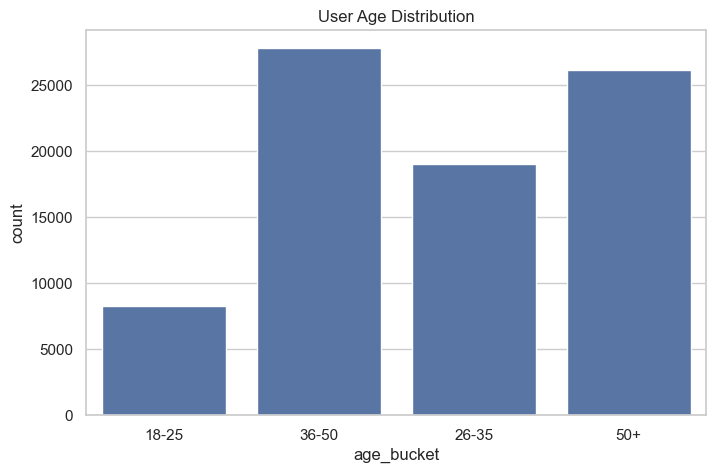

In [7]:
sns.countplot(x="age_bucket", data=df)
plt.title("User Age Distribution")
plt.show()

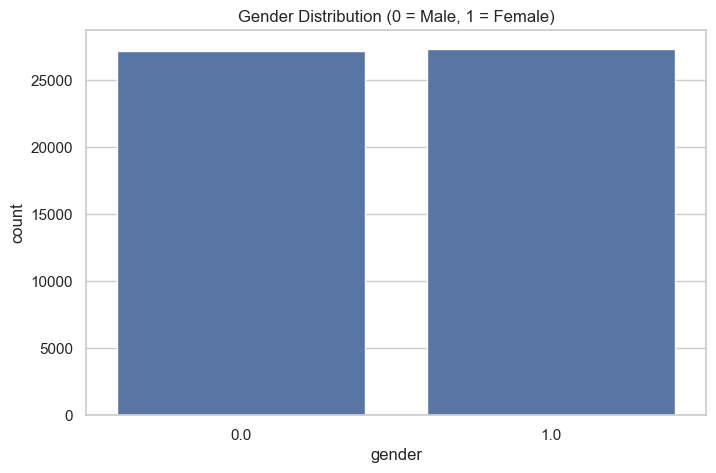

In [8]:
sns.countplot(x="gender", data=df)
plt.title("Gender Distribution (0 = Male, 1 = Female)")
plt.show()

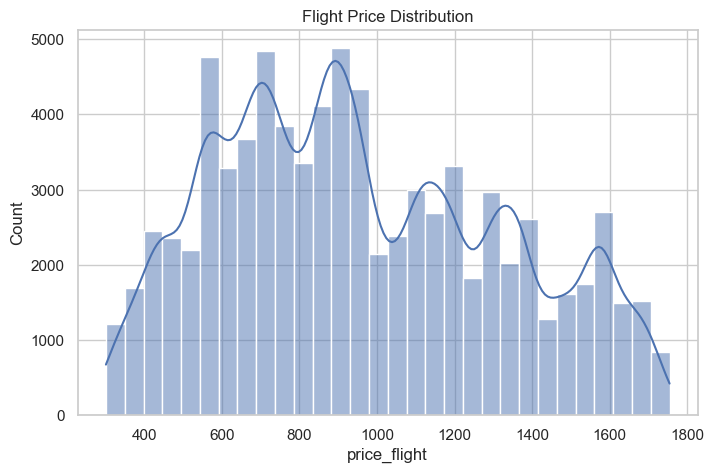

In [9]:
sns.histplot(df["price_flight"], bins=30, kde=True)
plt.title("Flight Price Distribution")
plt.show()

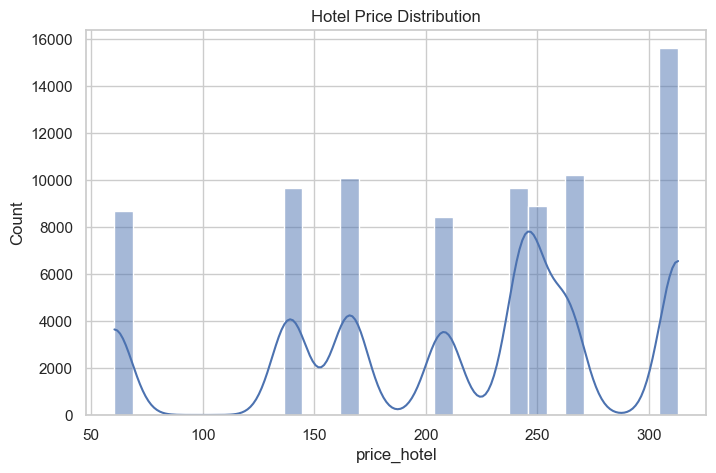

In [10]:
sns.histplot(df["price_hotel"], bins=30, kde=True)
plt.title("Hotel Price Distribution")
plt.show()

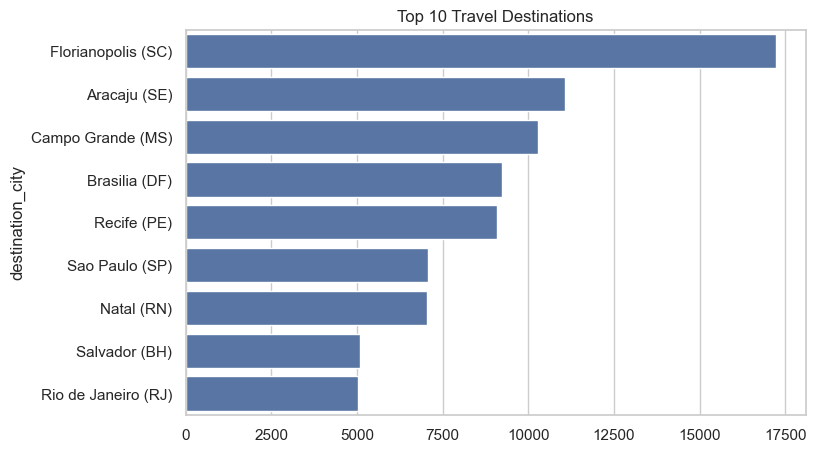

In [11]:
top_destinations = df["destination_city"].value_counts().head(10)

sns.barplot(
    x=top_destinations.values,
    y=top_destinations.index
)
plt.title("Top 10 Travel Destinations")
plt.show()

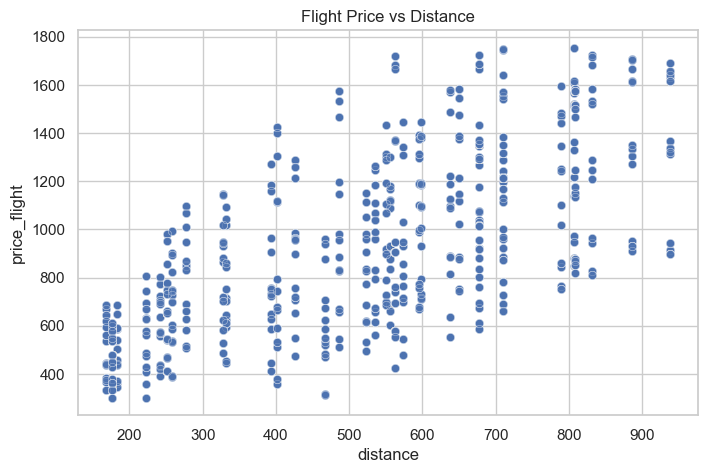

In [13]:
sns.scatterplot(
    x="distance",
    y="price_flight",
    data=df,
    alpha=0.4
)
plt.title("Flight Price vs Distance")
plt.show()

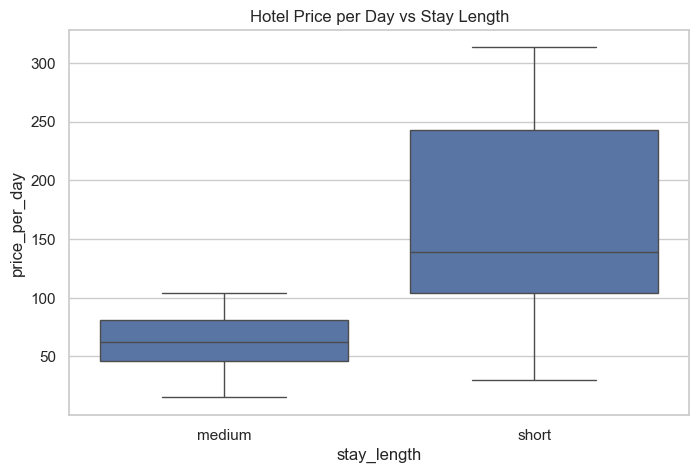

In [14]:
sns.boxplot(
    x="stay_length",
    y="price_per_day",
    data=df
)
plt.title("Hotel Price per Day vs Stay Length")
plt.show()

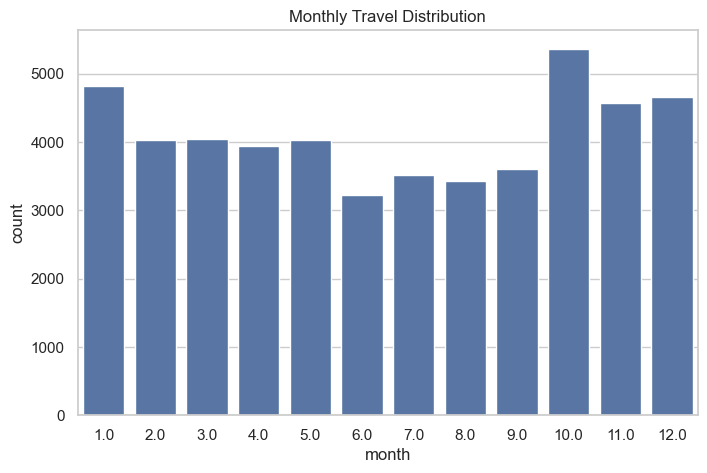

In [15]:
sns.countplot(x="month", data=df)
plt.title("Monthly Travel Distribution")
plt.show()

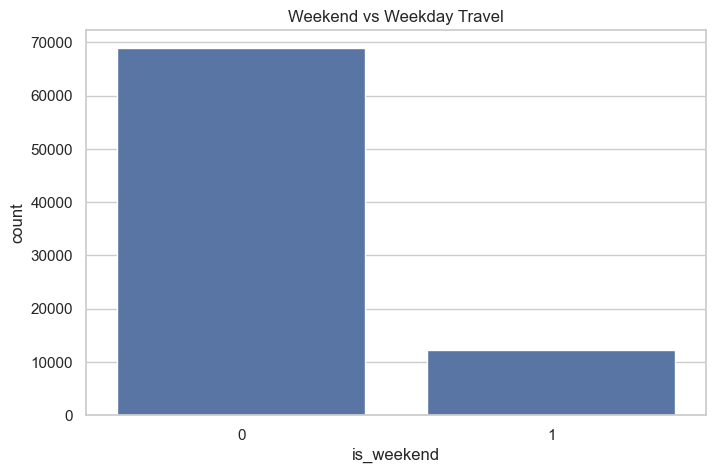

In [16]:
sns.countplot(x="is_weekend", data=df)
plt.title("Weekend vs Weekday Travel")
plt.show()

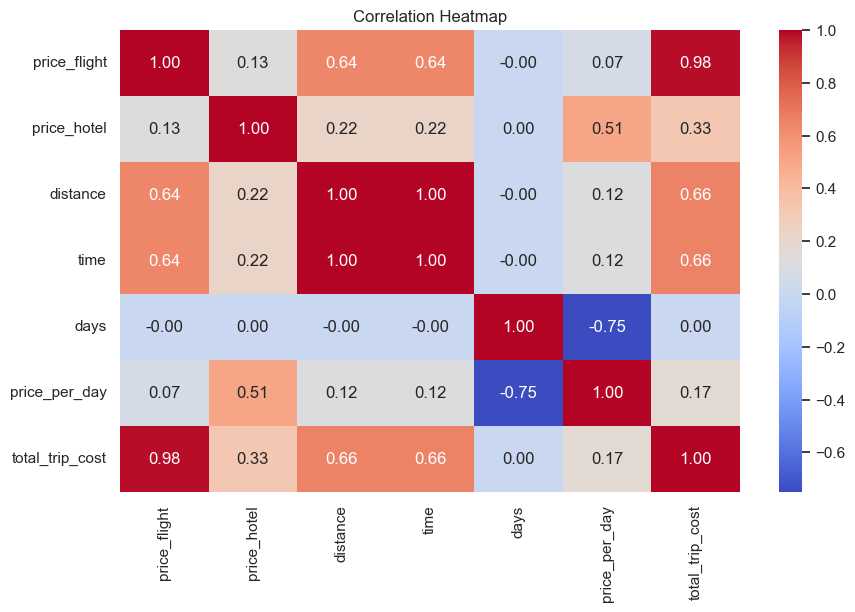

In [17]:
num_cols = [
    "price_flight",
    "price_hotel",
    "distance",
    "time",
    "days",
    "price_per_day",
    "total_trip_cost"
]

corr = df[num_cols].corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

Text(0.5, 1.0, 'Distribution of Flight Prices')

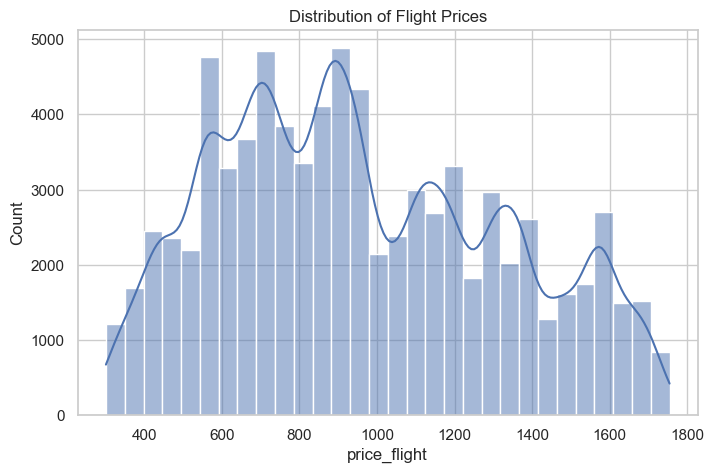

In [18]:
sns.histplot(df["price_flight"], bins=30, kde=True)
plt.title("Distribution of Flight Prices")

Text(0.5, 1.0, 'Flight Price vs Duration')

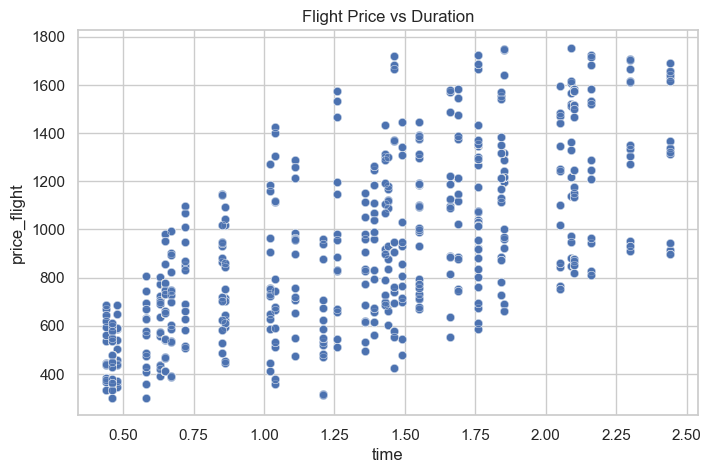

In [19]:
sns.scatterplot(x="time", y="price_flight", data=df, alpha=0.4)
plt.title("Flight Price vs Duration")

Text(0.5, 1.0, 'Monthly Flight Distribution')

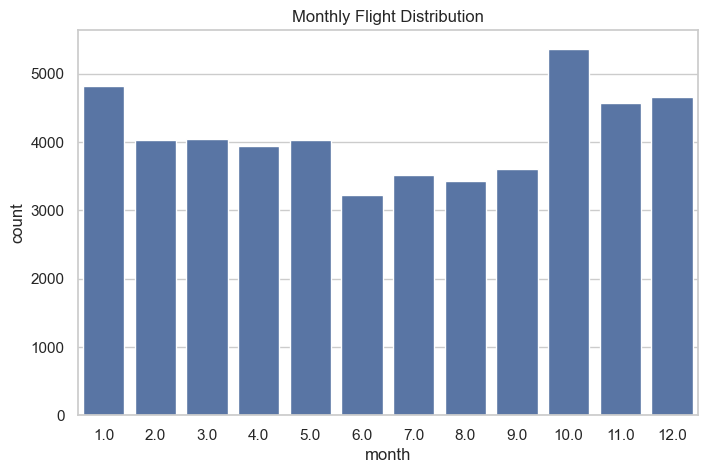

In [20]:
sns.countplot(x="month", data=df)
plt.title("Monthly Flight Distribution")

Text(0.5, 1.0, 'Top 10 Flight Routes')

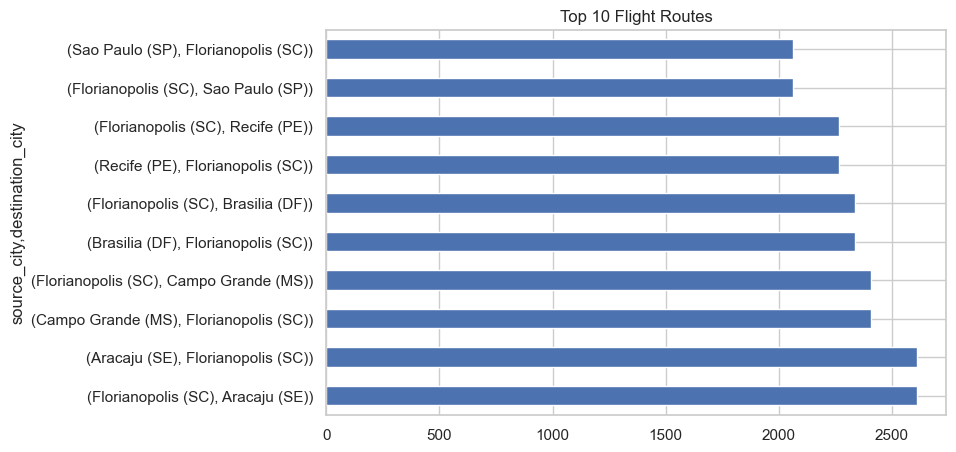

In [21]:
top_routes = (
    df.groupby(["source_city", "destination_city"])
    .size()
    .sort_values(ascending=False)
    .head(10)
)

top_routes.plot(kind="barh")
plt.title("Top 10 Flight Routes")

In [22]:
importances = pipeline.named_steps["model"].feature_importances_

NameError: name 'pipeline' is not defined